# DATA-445 In-Class Assignment 3

Consider the `framingham.csv` data file. The dataset is publicly available on the Kaggle website, and it is from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts. The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD). The dataset provides the patients' information. It includes over 4,000 records and 15 attributes. Each attribute is a potential risk factor. There are demographic, behavioral, and medical risk factors.

- **Demographic:**
  - Sex: male or female (Nominal)
  - Age: Age of the patient (Continuous)
- **Behavioral:**
  - Current Smoker: whether or not the patient is a current smoker (Nominal)
  - Cigs Per Day: the number of cigarettes that the person smoked on average in one day (Continuous)
- **Medical (history):**
  - BP Meds: whether or not the patient was on blood pressure medication (Nominal)
  - Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)
  - Prevalent Hyp: whether or not the patient was hypertensive (Nominal)
  - Diabetes: whether or not the patient had diabetes (Nominal)
- **Medical (current):**
  - Tot Chol: total cholesterol level (Continuous)
  - Sys BP: systolic blood pressure (Continuous)
  - Dia BP: diastolic blood pressure (Continuous)
  - BMI: Body Mass Index (Continuous)
  - Heart Rate: heart rate (Continuous)
  - Glucose: glucose level (Continuous)
- **Predict variable (desired target):**
  - 10 year risk of coronary heart disease CHD (binary: "1" means "Yes", "0" means "No")

## 1. (3 points) Using the pandas library, read the csv data file and create a data-frame called `heart`.

In [14]:
import pandas as pd

heart = pd.read_csv("framingham.csv")
heart.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 2. (3 points) Remove observations with missing values.

In [15]:
heart.info()

# The int64 means that the data type is an integer. Also it is taking up 64 bits of memory.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [16]:
heart.isnull().sum()

# Education has 105 missing values 

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [17]:
heart = heart.dropna()

heart.shape

# After removing the rows the dataframe now has 3656 rows and 16 columns.

(3656, 16)

## 3. (4 points) Create a scatter plot of `BMI` and `heartRate`. Describe the plot.

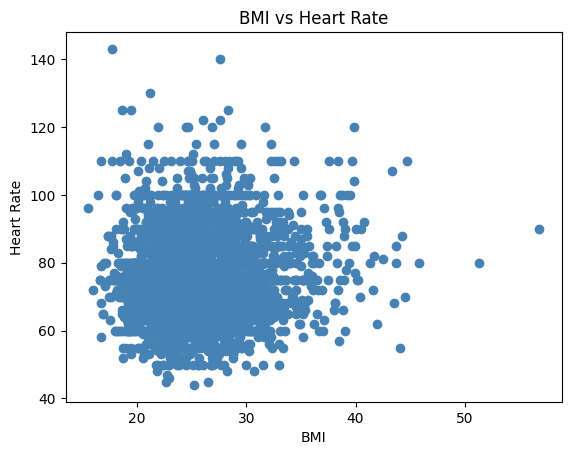

In [18]:
import matplotlib.pyplot as plt

plt.plot(heart["BMI"], heart["heartRate"], "o", color="steelblue")
plt.title("BMI vs Heart Rate")
plt.xlabel("BMI")
plt.ylabel("Heart Rate")
plt.show()


 from the above scatterplot we do not see any specific relationship between 'BMI' and 'heartrate'

## 4. (4 points) Create a scatter plot of `glucose` and `BMI`. Describe the plot.

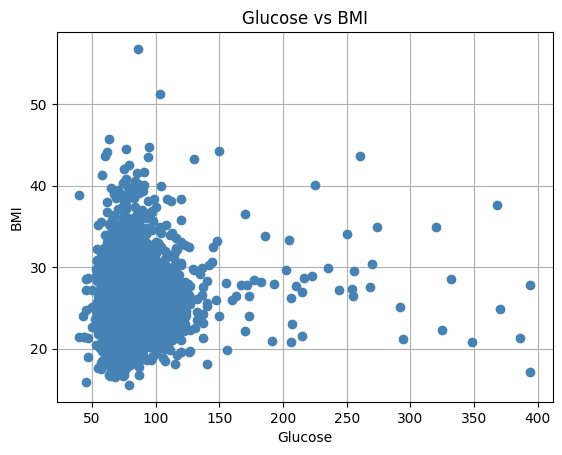

In [19]:
plt.plot(heart["glucose"], heart["BMI"], "o", color="steelblue")
plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.grid()
plt.show()

from the above scatter plot we dont see any specific relationship between glucose and BMI

## 5. (5 points) Build a logistic regression model in which: `age`, `currentSmoker`, `totChol`, `BMI`, and `heartRate` are the predictor variables, and `TenYearCHD` is the target variable.

In [20]:
from sklearn.linear_model import LogisticRegression

x = heart[['age', 'currentSmoker', 'totChol', 'BMI', 'heartRate']]
y = heart["TenYearCHD"]

model = LogisticRegression()
model.fit(x, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 6. (3 points) Using the model from part 5, predict the likelihood of risk of coronary disease of a patient with the following characteristics: `age = 50`, `currentSmoker = 1`, `totChol = 250`, `BMI = 27`, and `heartRate = 85`.

In [22]:
# Defining a new patient with the following characterisitics:

new_df = pd.DataFrame ({
    "age": [50],
    "currentSmoker": [1],
    "totChol": [250],
    "BMI": [27],
    "heartRate": [85]
})

# prediciting the likelihood of developing coronary heart disease in the next 10 years for the 
prediction = model.predict_proba(new_df)
prediction 

array([[0.81930797, 0.18069203]])